## 1) Linear Layer: forward + manual backward

**Description**

Implement a fully-connected layer y = xW + b with manual backward that returns gradients for x, W, b. Assume x: (B, in), W: (in, out), b: (out).

In [45]:
import torch
import torch.nn as nn

x = torch.tensor([[1,2], [3,4.]])
y = torch.tensor([[4, 7], [8, 9.], [0, 1]])

torch.einsum("nd,md->nm", x, y)

tensor([[18., 26.,  2.],
        [40., 60.,  4.]])

In [9]:
print((1<<2)-1)

3


In [55]:
#z = torch.randn(2,2,4)
print(z)
z[x==2, 0]

tensor([[[-0.4999, -0.1768, -0.3427, -0.2572],
         [-0.1700, -0.6650, -1.0342,  1.7918]],

        [[-0.2933, -0.9983, -1.5092,  1.0886],
         [-0.8319,  0.0846, -0.9221,  0.5356]]])


tensor([-0.1700])

In [41]:
x = torch.randn(2, 3, 2, 2)
y = torch.randn(3, 2, 1)
z = x @ y
print(x.shape, y.shape, z.shape)

torch.Size([2, 3, 2, 2]) torch.Size([3, 2, 1]) torch.Size([2, 3, 2, 1])


In [42]:
print(x, y, z)

tensor([[[[-0.3101,  1.5267],
          [ 0.0173,  0.9598]],

         [[ 0.0148,  1.9912],
          [-0.8823, -0.6996]],

         [[ 0.4685,  0.5479],
          [-0.1338,  0.1675]]],


        [[[-0.6533,  0.5415],
          [-1.1573, -1.0938]],

         [[ 1.0088, -0.9680],
          [ 1.8919,  0.6402]],

         [[-0.9421, -1.4055],
          [ 0.6085, -0.8711]]]]) tensor([[[-0.8541],
         [-1.0728]],

        [[ 0.2236],
         [ 0.3136]],

        [[-0.4281],
         [ 0.1434]]]) tensor([[[[-1.3729],
          [-1.0445]],

         [[ 0.6277],
          [-0.4167]],

         [[-0.1221],
          [ 0.0813]]],


        [[[-0.0229],
          [ 2.1619]],

         [[-0.0779],
          [ 0.6238]],

         [[ 0.2019],
          [-0.3854]]]])


In [19]:
x = [nn.Linear(1,2), nn.Linear(5,2)]
for t in x:
    print(t)

Linear(in_features=1, out_features=2, bias=True)
Linear(in_features=5, out_features=2, bias=True)


In [1305]:
import torch
import math

class CustomLinear:
    def __init__(self, d_in: int, d_out: int):
        self.d_in = d_in
        self.d_out = d_out
        self.W = torch.randn((d_out, d_in), requires_grad=True) # He- init to have same variance in each layer. 
        self.W.data.mul_(math.sqrt(4 / (d_out + d_in)))
        self.b = torch.zeros(d_out, requires_grad=True)

    def forward(self, input: torch.tensor):
        # input: B x d_in
        # output: B x d_out
        return input @ self.W.T + self.b
    
    def backward(self, input: torch.tensor, output_grad: torch.tensor):
        # input: B x d_in
        # output_grad: B x d_out

        dL_W = output_grad.T @ input
        dL_b = output_grad.sum(dim=0)
        dL_input = output_grad @ self.W


        return dL_input, dL_W, dL_b

In [1304]:
def test_linear_backward():
    torch.manual_seed(0)

    B, d_in, d_out = 100, 10, 20

    model = CustomLinear(d_in, d_out)

    input = torch.randn((B, d_in), requires_grad=True)
    output = model.forward(input)
    dO = torch.randn((B, d_out))
    # custom backward
    dinput, dW, db = model.backward(input, dO)
    # autograd backward
    output.backward(dO)
    # compare
    torch.testing.assert_close(dinput, input.grad, rtol=1e-9, atol=1e-9)
    torch.testing.assert_close(dW, model.W.grad, rtol=1e-9, atol=1e-9)
    torch.testing.assert_close(db, model.b.grad, rtol=1e-9, atol=1e-9)

    print("Passed!!")

test_linear_backward()

Passed!!


## 2) MSE Loss: forward + backward

**Description**

Implement mean squared error and its gradient wrt predictions.

In [157]:
class CustomMSELoss:
    def __call__(self, y_true: torch.tensor, y_pred: torch.tensor):
        assert y_true.shape == y_pred.shape, f"{y_true.shape=} != {y_pred.shape=}"
        self.diff = y_pred - y_true
        return torch.mean(self.diff ** 2)
    
    def backward(self):
        return self.diff * 2 / self.diff.numel()

# Plan:

### 1. Generate linear dependent data with some noise in the target.

### 2. Implement linear regression training pipeline using two classes that we have: Linear + MSE.

In [293]:
# 1. Generate data
import torch
import matplotlib.pyplot as plt 
import numpy as np

N = 100 # num samples
k = 5 # num features EXCLUDING bias

W_true = torch.randn((k+1))

X_linear = torch.randn((N, k))
y_linear = X_linear @ W_true[:k] + W_true[-1] + torch.randn(len(X_linear))*0.05


def split_data(X: torch.tensor, y: torch.tensor, train_test_ration: float =0.8):
    train_size = int(len(X) * train_test_ration)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    return X_train, y_train, X_test, y_test



def plot(X: torch.tensor, y: torch.tensor, prediction=None):
    # plot only first feature:
    sorted_idxes = torch.argsort(X[:, 0])
    X = X[sorted_idxes, 0]
    y = y[sorted_idxes]
    plt.scatter(np.array(X.tolist()), np.array(y.tolist()))
    if prediction is not None:
        prediction = prediction[sorted_idxes]
        plt.plot(np.array(X.tolist()), np.array(prediction.tolist()), label="prediction")
        plt.show()

    plt.show()


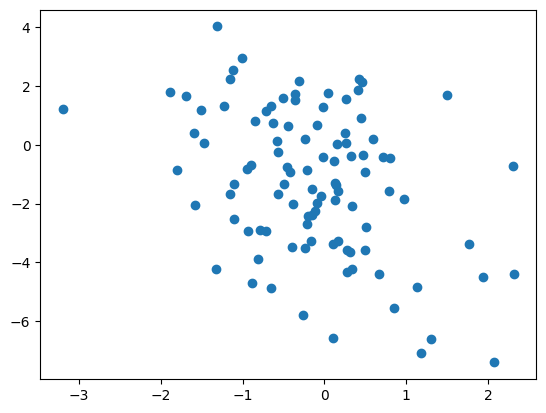

In [295]:
# only first feature
plot(X_linear, y_linear)

In [397]:
from IPython.display import clear_output

def normalize_train_test(X_train: torch.tensor, X_test: torch.tensor, eps: float =1e-8):
    mean = X_train.mean(dim=0, keepdim=True)          # (1, d)
    std  = X_train.std(dim=0, keepdim=True) + eps     # (1, d)
    return (X_train - mean) / std, (X_test - mean) / std


def train(X_train, y_train, X_test, y_test, normalize_features=False, num_epochs=100, lr = 0.1, reguralize = False):
    linear_model = CustomLinear(d_in = X_train.shape[-1], d_out = 1)
    mse_loss = CustomMSELoss()
    train_loss = []

    if normalize_features:
        X_train, X_test = normalize_train_test(X_train, X_test)


    for epoch in range(num_epochs):
        y_pred = linear_model.forward(X_train) # X_train: N x k
        loss = mse_loss(y_train[:, None], y_pred)

        dL_y_pred = mse_loss.backward() # N, 1
        
        _, dL_W, dL_b = linear_model.backward(X_train, dL_y_pred)

        if reguralize:
            wd = 1e-3
            linear_model.W -= lr * wd * linear_model.W

        
        linear_model.W -= lr * dL_W
        linear_model.b -= lr * dL_b

        if epoch % 50 == 0:
            clear_output(wait=True)
            train_loss.append(loss.item())
            plt.plot(np.array(train_loss))
            plt.show()


    y_test_pred = X_test @ linear_model.W.T + linear_model.b.T
    print(f"True weights: {W_true[:-1]}, Trained weights: {linear_model.W.T}")
    print(f"Test mse loss: {mse_loss(y_test[:, None], y_test_pred)}")
    plot(X_test, y_test, y_test_pred)
    print(train_loss)





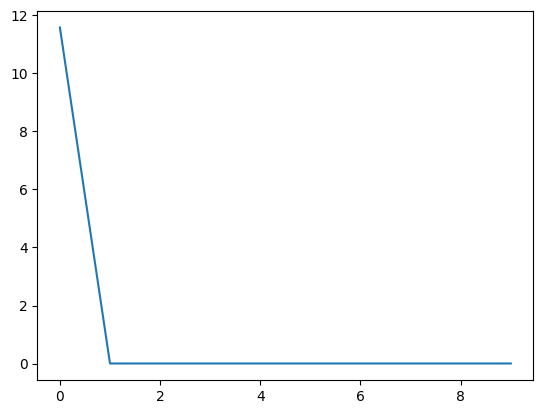

True weights: tensor([-0.8637,  0.2728, -1.0990, -0.8076, -1.4715]), Trained weights: tensor([[-0.8611],
        [ 0.2744],
        [-1.0959],
        [-0.8178],
        [-1.4654]])
Test mse loss: 0.0029924879781901836


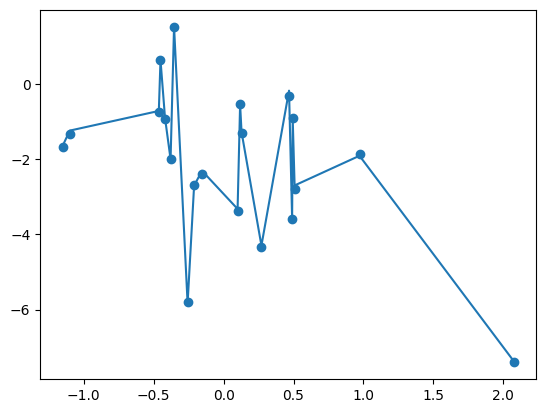

[11.579341888427734, 0.0028098495677113533, 0.0028095035813748837, 0.0028095014858990908, 0.0028095014858990908, 0.0028095014858990908, 0.0028095014858990908, 0.0028095014858990908, 0.0028095014858990908, 0.0028095014858990908]


In [400]:
X_train, y_train, X_test, y_test = split_data(X_linear, y_linear)
train(X_train, y_train, X_test, y_test, num_epochs=500)

In [401]:
k = 5
X_polinomial = torch.randn((N, 1))
X_polinomial = torch.concat(tuple(X_polinomial ** i for i in range(1, k+1)), dim=1)
y_polinomial = X_polinomial @ W_true[:k] + W_true[-1] + torch.randn(len(X_polinomial))*0.05

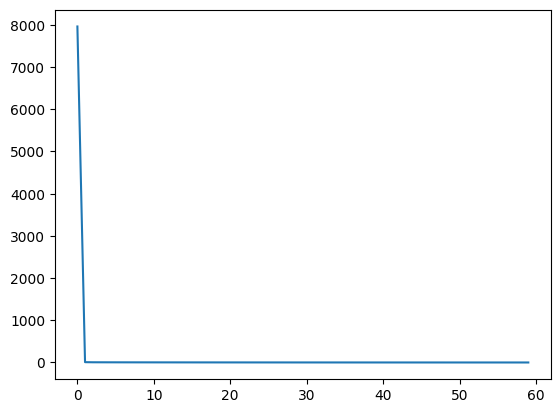

True weights: tensor([-0.8637,  0.2728, -1.0990, -0.8076, -1.4715]), Trained weights: tensor([[  0.1053],
        [  1.4402],
        [-11.3356],
        [-15.5955],
        [-64.1633]])
Test mse loss: 1.2908624410629272


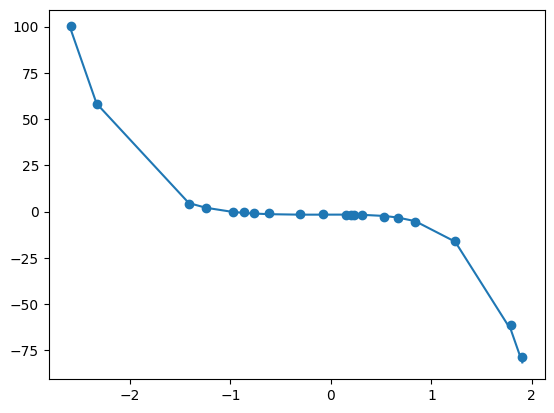

[7962.1591796875, 7.753936767578125, 5.106988430023193, 4.621807098388672, 4.246851444244385, 3.938978910446167, 3.678924083709717, 3.453624725341797, 3.2541656494140625, 3.0744616985321045, 2.9102561473846436, 2.7586183547973633, 2.6174466609954834, 2.485217332839966, 2.3608498573303223, 2.2434935569763184, 2.1325020790100098, 2.027365207672119, 1.92766535282135, 1.8330230712890625, 1.7431528568267822, 1.6577593088150024, 1.5766109228134155, 1.499468445777893, 1.4261319637298584, 1.3563998937606812, 1.29009211063385, 1.2270396947860718, 1.1670799255371094, 1.1100581884384155, 1.0558280944824219, 1.004256248474121, 0.9552100896835327, 0.9085666537284851, 0.864200234413147, 0.8220077753067017, 0.7818809151649475, 0.743721067905426, 0.7074258327484131, 0.6729108691215515, 0.6400808095932007, 0.6088637113571167, 0.5791714191436768, 0.5509318113327026, 0.524076521396637, 0.49853330850601196, 0.47424373030662537, 0.4511379599571228, 0.4291677474975586, 0.408270925283432, 0.3883987069129944,

In [618]:
#X_train, y_train, X_test, y_test = split_data(X_polinomial, y_polinomial)
train(X_train, y_train, X_test, y_test, normalize_features=True, num_epochs=3000, reguralize=False)

## Simple training pipeline using torch

In [802]:
from IPython.display import clear_output
import matplotlib.pyplot as plt
import torch

def pytorch_train(X_train, y_train, model, optim, loss_fn, epochs=1000, batch_size=32, plot_every=20):
    train_loss = []
    model.train()

    # ensure shapes match model output (B,1)
    if y_train.ndim == 1:
        y_train = y_train.unsqueeze(1)

    num_batches = (len(X_train) + batch_size - 1) // batch_size

    for epoch in range(epochs):
        for start in range(0, len(X_train), batch_size):
            X_batch = X_train[start:start + batch_size]
            y_batch = y_train[start:start + batch_size]

            y_pred = model(X_batch)
            batch_loss = loss_fn(y_pred, y_batch)

            optim.zero_grad()
            batch_loss.backward()
            optim.step()

            iteration = epoch * num_batches + (start // batch_size)
            if iteration % plot_every == 0:
                train_loss.append(batch_loss.item())
                clear_output(wait=True)
                plt.plot(train_loss)
                plt.xlabel("log step")
                plt.ylabel("MSE")
                plt.show()

    return train_loss

@torch.no_grad()
def evaluate(model, X_test, y_test, loss_fn, batch_size=32):
    model.eval()
    if y_test.ndim == 1:
        y_test = y_test.unsqueeze(1)

    y_test_pred = []

    total_loss, total_n = 0.0, 0
    for start in range(0, len(X_test), batch_size):
        X_batch = X_test[start:start + batch_size]
        y_batch = y_test[start:start + batch_size]

        y_pred = model(X_batch)
        batch_loss = loss_fn(y_pred, y_batch)

        total_loss += batch_loss.item() * len(X_batch)
        total_n += len(X_batch)

        y_test_pred.append(y_pred)
    
    y_test_pred = torch.concat(y_test_pred, dim=-1)
    plot(X_test, y_test, y_test_pred)


In [796]:
N=100
k = 5

X_polinomial = torch.randn((N, 1))
X_polinomial = torch.concat(tuple(X_polinomial ** i for i in range(1, k+1)), dim=1)
y_polinomial = X_polinomial @ W_true[:k] + W_true[-1] + torch.randn(len(X_polinomial))*0.05

X_train, y_train, X_test, y_test = split_data(X_polinomial, y_polinomial)

X_train, X_test = normalize_train_test(X_train, X_test)

In [800]:
model = torch.nn.Sequential(
    torch.nn.Linear(k, 1)
)
optim = torch.optim.SGD(model.parameters(), lr=0.01)
mse_loss = torch.nn.MSELoss()


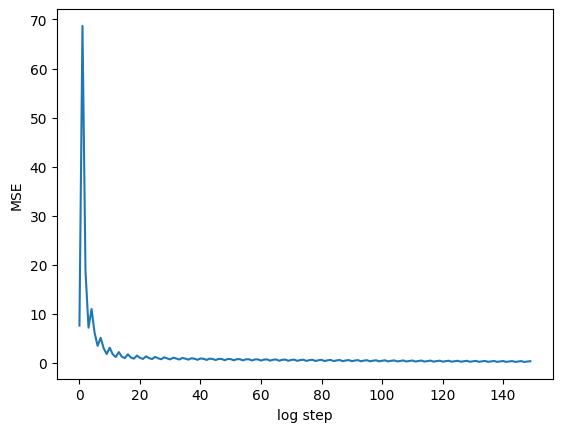

Eval loss: 0.7086009979248047


In [801]:
pytorch_train(X_train, y_train, model, optim, mse_loss, epochs=1000)
eval(model, X_test, y_test, mse_loss)

## 3) Sigmoid: stable forward + backward

**Description**

Implement numerically-stable sigmoid and its derivative.

## Plan:

sigmoid(x) = 1 / (1 + exp(-x))

if x is a positive number then exp(-x) will be smalle, so everything fine.

if x is a large negative number then exp(-x) can be huge. Let's express it using exp(x):

sigmoid(x) = 1 / (1 + exp(-x)) = exp(x) / (1 + exp(x))



In [414]:
class Sigmoid:
    def __call__(self, x):
        # x: (B, 1) or any shape
        out = torch.empty_like(x)

        pos = x >= 0
        neg = ~pos  

        out[pos] = 1 / (1 + torch.exp(-x[pos]))

        exp_x = torch.exp(x[neg])
        out[neg] = exp_x / (1 + exp_x)

        self.out = out
        return out

    def backward(self, output_grad):
        # output_grad: same shape as self.out
        return output_grad * (self.out * (1 - self.out))


In [434]:
x = torch.tensor([-13.6364, 2, 4, 1e1000, -1e1000])
custom_sig = Sigmoid()(x)
torch_sig = torch.sigmoid(x)

print(abs(custom_sig - torch_sig).max())

tensor(1.1369e-13)


In [1312]:
def test_sigmoid_backward():
    torch.manual_seed(0)

    B = 100

    sigmoid = Sigmoid()

    input = torch.randn((B, 1), requires_grad=True)
    output = sigmoid(input)
    dO = torch.randn((B, 1))
    # custom backward
    dinput = sigmoid.backward(dO)
    # autograd backward
    output.backward(dO)
    # compare
    torch.testing.assert_close(dinput, input.grad, rtol=1e-7, atol=1e-7)


    print("Passed!!")

test_sigmoid_backward()

Passed!!


## 4) ReLU: forward + backward

**Description**

Implement ReLU and gradient mask.

In [435]:
class ReLU:
    def __call__(self, input):
        # input: B x ..
        self.mask = input > 0
        return input * self.mask.to(input.dtype)
    
    def backward(self, output_grad):
        return output_grad * self.mask.to(output_grad.dtype)

In [437]:
x = torch.randn(10)
print(x)
print(ReLU()(x))

tensor([-1.0415, -0.9186,  0.9021, -0.8747, -0.7544,  0.4486, -1.7421,  0.9008,
        -1.0084, -0.7750])
tensor([-0.0000, -0.0000, 0.9021, -0.0000, -0.0000, 0.4486, -0.0000, 0.9008, -0.0000,
        -0.0000])


In [1316]:
def test_relu_backward():
    torch.manual_seed(0)

    B = 100

    relu = ReLU()

    input = torch.randn((B, 100), requires_grad=True)
    output = relu(input)
    dO = torch.randn_like(input)
    # custom backward
    dinput = relu.backward(dO)
    # autograd backward
    output.backward(dO)
    # compare
    torch.testing.assert_close(dinput, input.grad, rtol=1e-7, atol=1e-7)


    print("Passed!!")

test_relu_backward()

Passed!!


## 5) Softmax: stable forward

**Description**

Implement stable softmax along last dim.


### Plan:

Softmax consists from exponents. In order to avoid overflows we can substract max value from all values in x and then calculate softmax. The results will be same but we avoid overflow.

softmax(x) = softmax(x - max(x))

In [443]:
class Softmax:
    def __call__(self, input):
        # input : B x D
        input = input - input.max(dim=-1, keepdim=True).values
        input = torch.exp(input)
        input /= input.sum(dim=-1, keepdim=True)
        return input
    

In [472]:
input = torch.randn(10, 100)*1e1

custom_softmax = Softmax()(input)
torch_softmax = torch.softmax(input, dim=-1)

print(abs(custom_softmax - torch_softmax).max())

tensor(1.1921e-07)


## 6) Cross-Entropy from scratch (softmax + NLL): forward + backward

**Description**

Given logits (B, C) and integer labels (B,), compute CE loss and gradient wrt logits.

### Plan:

probs = softmax(x), # x : B x C, labels: B (one hot encoding)
cross_entropy = sum_i [-log probs_i_k] = -sum_i [x_i_k - log sum exp(x_i_j)]

dprobs_x = concat[diag(x) - x @ x.T]
dcross_entropy_x = probs - labels

In [531]:
class CrossEntropyLoss:
    def __call__(self, logits, labels):
        B, C = logits.shape

        # shift for stability
        z = logits - logits.max(dim=1, keepdim=True).values

        # logsumexp
        log_sum_exp = torch.log(torch.exp(z).sum(dim=1))  # (B,)

        # loss
        loss = (-z[torch.arange(B), labels] + log_sum_exp).mean()

        # gradient
        probs = torch.exp(z) / torch.exp(z).sum(dim=1, keepdim=True)
        grad = probs
        grad[torch.arange(B), labels] -= 1
        grad /= B

        self.grad = grad
        return loss

    def backward(self):
        return self.grad


In [532]:
logits = torch.randn(10, 15)
labels = torch.randint(0, 15, (10,))

custom_cross_entropy = CrossEntropyLoss()(logits, labels)
torch_cross_entropy = torch.nn.CrossEntropyLoss()(logits, labels)

print(abs(custom_cross_entropy.item() - torch_cross_entropy.item()))

4.76837158203125e-07


In [1322]:
def test_cross_entropy_backward():
    torch.manual_seed(0)

    B, C = 100, 10

    cross_entropy_loss = CrossEntropyLoss()

    logits = torch.randn((B, C), requires_grad=True)
    labels = torch.randint(0, C, size=(B,))

    loss = cross_entropy_loss(logits, labels)
    # custom backward
    dlogits = cross_entropy_loss.backward()
    # autograd backward
    loss.backward()
    # compare
    torch.testing.assert_close(dlogits, logits.grad, rtol=1e-7, atol=1e-7)


    print("Passed!!")

test_cross_entropy_backward()

Passed!!


## 7) SGD optimizer (using torch grads)

**Description**

Write a function that updates parameters in-place using .grad, with optional weight decay and momentum.

In [773]:
class SGDOptimizer:
    def __init__(self, parameters, lr):
        self.parameters = list(parameters) # model.parameters() is a generator, so we can iterate over in once. We need to convert to list
        self.lr = lr
    
    def zero_grad(self):
        for param in self.parameters:
            param.grad = None

    def step(self):
        with torch.no_grad(): # We need this for proper versioning.
            for param in self.parameters:
                if param.grad is not None:
                    param -= self.lr * param.grad

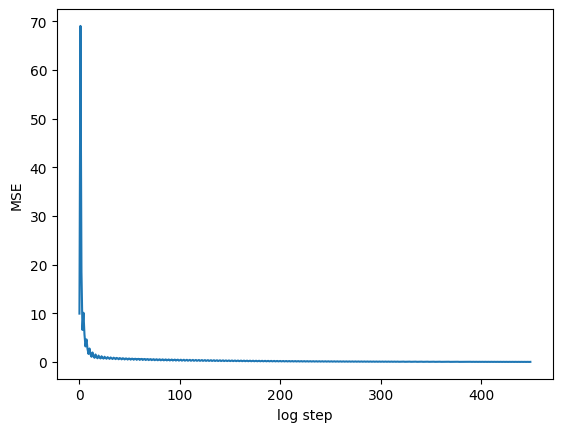

Eval loss: 0.04353171959519386
Parameter containing:
tensor([[ -0.1417,  -0.5384,  -1.1100,   2.4965, -14.0417]],
       requires_grad=True)
Parameter containing:
tensor([-2.0464], requires_grad=True)


In [803]:
# Torch Optimizer

model = torch.nn.Linear(k, 1) 
mse_loss = torch.nn.MSELoss()
torch_optim = torch.optim.SGD(model.parameters(), lr=0.01)

pytorch_train(X_train, y_train, model, torch_optim, mse_loss, epochs=3000)
eval(model, X_test, y_test, mse_loss)
for param in model.parameters():
    print(param)

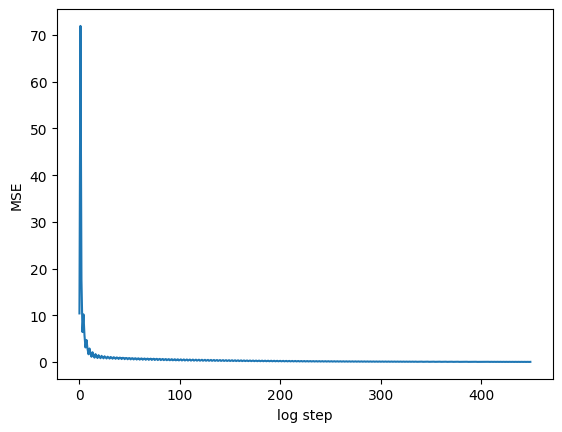

450
Eval loss: 0.05242616683244705
Parameter containing:
tensor([[ -0.1128,  -0.5255,  -1.2025,   2.4783, -13.9666]],
       requires_grad=True)
Parameter containing:
tensor([-2.0454], requires_grad=True)


In [804]:
# Custom Optimizer

model = torch.nn.Linear(k, 1) 
mse_loss = torch.nn.MSELoss()
custom_optim = SGDOptimizer(model.parameters(), lr=0.01)

print(len(pytorch_train(X_train, y_train, model, custom_optim, mse_loss, epochs=3000)))
eval(model, X_test, y_test, mse_loss)
for param in model.parameters():
    print(param)

## 8) Linear regression: closed-form normal equation

**Description**

Fit y = Xw (no bias) using (XᵀX)⁻¹Xᵀy. Use pseudo-inverse for stability.

In [850]:
class LinearRegression:
    def fit(self, X, y):
        self.mean = X.mean(dim=0, keepdim=True)
        self.std = X.std(dim=0, keepdim=True) + 1e-12
        X = (X - self.mean) / self.std
        X = torch.concat((X, torch.ones(X.shape[0], 1)), dim=1)
        self.w = torch.linalg.pinv(X.T@X)@(X.T@y)
        return self

    def predict(self, X):
        X = (X - self.mean) / self.std
        X = torch.concat((X, torch.ones(X.shape[0], 1)), dim=1)
        return X@self.w

In [851]:
N=100
k = 5

X_polinomial = torch.randn((N, 1))
W_true = torch.randn(k)

X_polinomial = torch.concat(tuple(X_polinomial ** i for i in range(1, k+1)), dim=1)
y_polinomial = X_polinomial @ W_true[:k] #+ torch.randn(len(X_polinomial))*0.05

X_train, y_train, X_test, y_test = split_data(X_polinomial, y_polinomial)


In [854]:
reg = LinearRegression().fit(X_train, y_train)

y_pred = reg.predict(X_test)
mse_loss = torch.mean((y_pred - y_test) ** 2)

print("MSE Loss:", mse_loss)


MSE Loss: tensor(6.0441e-09)


## 9) Linear regression: gradient descent

**Description**

Implement GD for MSE minimizing w,b from scratch.

In [855]:
N=100
k = 5

X_polinomial = torch.randn((N, 1))
W_true = torch.randn(k+1)

X_polinomial = torch.concat(tuple(X_polinomial ** i for i in range(1, k+1)), dim=1)
y_polinomial = X_polinomial @ W_true[:k] + W_true[-1] + torch.randn(len(X_polinomial))*0.05

X_train, y_train, X_test, y_test = split_data(X_polinomial, y_polinomial)

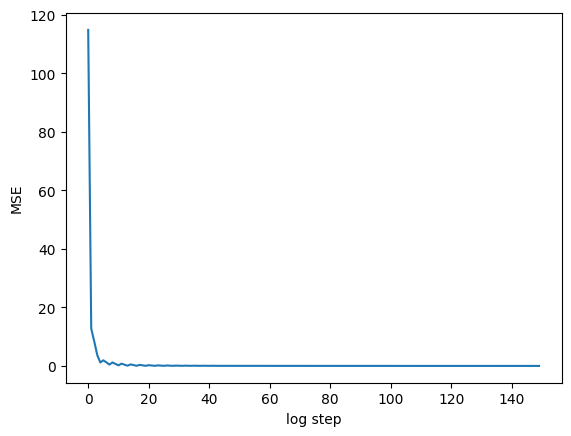

In [869]:
W = torch.randn(k)
b = torch.randn(1)

epochs = 1000
lr = 0.01
batch_size = 32

X_train, X_test = normalize_train_test(X_train, X_test)

num_batches = (len(X_train) + batch_size - 1) // batch_size
train_loss = []

for epoch in range(epochs):
    for start in range(0, len(X_train), batch_size):
        X_batch, y_batch = X_train[start:start + batch_size], y_train[start:start+batch_size]

        y_pred = X_batch@W + b 
        diff = y_pred - y_batch
        loss = torch.mean(diff ** 2)

        dL_y = 2 * diff / len(X_batch) # B x 1
        dL_W = X_batch.T @ dL_y
        dL_b = dL_y.sum(dim=0)

        W -= lr * dL_W
        b -= lr * dL_b

        iteration = epoch * num_batches + (start // batch_size)
        if iteration % 20 == 0:
            train_loss.append(loss.item())
            clear_output(wait=True)
            plt.plot(train_loss)
            plt.xlabel("log step")
            plt.ylabel("MSE")
            plt.show()


In [871]:
y_test_pred =  X_test@W + b 
mse_loss = torch.mean((y_test_pred - y_test)**2)
print("Test mse", mse_loss)

Test mse tensor(0.0043)


## 10) Logistic regression: batch gradient descent

**Description**

Implement binary logistic regression for labels {0,1}, using BCE loss.

In [891]:
N=1000
k = 5

X_polinomial = torch.randn((N, 1))
W_true = torch.randn(k+1)

X_polinomial = torch.concat(tuple(X_polinomial ** i for i in range(1, k+1)), dim=1)
y_polinomial = (X_polinomial @ W_true[:k] + W_true[-1] + torch.randn(len(X_polinomial))*0.05 >= 0).to(torch.long)

X_train, y_train, X_test, y_test = split_data(X_polinomial, y_polinomial)

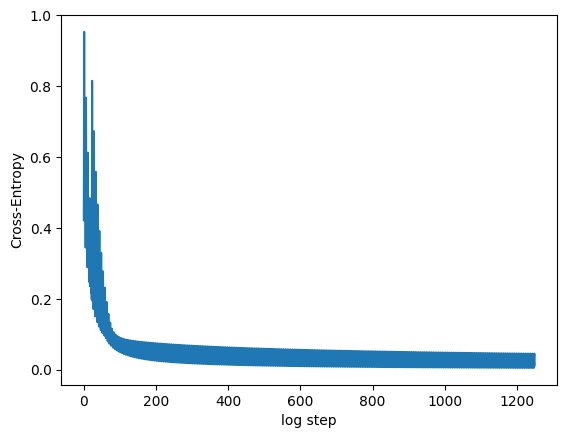

In [903]:
W = torch.randn(k)
b = torch.randn(1)

epochs = 1000
lr = 0.01
batch_size = 32

X_train, X_test = normalize_train_test(X_train, X_test)

num_batches = (len(X_train) + batch_size - 1) // batch_size
train_loss = []

for epoch in range(epochs):
    for start in range(0, len(X_train), batch_size):
        X_batch, y_batch = X_train[start:start + batch_size], y_train[start:start+batch_size].float()

        z = X_batch@W + b
        y_prob = torch.sigmoid(z)
        loss = -torch.mean(y_batch*torch.log(y_prob) + (1-y_batch)*torch.log(1-y_prob))

        dL_z = (y_prob - y_batch) / len(X_batch)
        dL_W = X_batch.T @ dL_z
        dL_b = dL_z.sum(dim=0)

        W -= lr * dL_W
        b -= lr * dL_b

        iteration = epoch * num_batches + (start // batch_size)
        if iteration % 20 == 0:
            train_loss.append(loss.item())
            clear_output(wait=True)
            plt.plot(train_loss)
            plt.xlabel("log step")
            plt.ylabel("Cross-Entropy")
            plt.show()


In [904]:
y_test_raw =  X_test@W + b 
y_test_prob = torch.sigmoid(y_test_raw)
y_test_pred = (y_test_prob >= 0.5).to(torch.long)

test_loss = -torch.mean(y_test*torch.log(y_test_prob) + (1-y_test)*torch.log(1-y_test_prob))
accuracy = torch.mean((y_test_pred == y_test).to(torch.float))

print("Test Cross-Entorpy", test_loss)
print("Test Accuracy", accuracy)

Test Cross-Entorpy tensor(0.0409)
Test Accuracy tensor(0.9850)


## 11) L2-regularized linear regression (Ridge)

**Description**

Implement ridge closed-form: (XᵀX + λI)⁻¹ Xᵀ y.

In [908]:
class RidgeLinearRegression:
    def fit(self, X, y, weight_decay = 0.01):
        # self.mean = X.mean(dim=0, keepdim=True)
        # self.std = X.std(dim=0, keepdim=True) + 1e-12
        self.weight_decay = weight_decay
        
        # X = (X - self.mean) / self.std
        # X = torch.concat((X, torch.ones(X.shape[0], 1)), dim=1)
        self.w = torch.linalg.pinv(X.T@X + weight_decay*torch.eye(X.shape[1]))@(X.T@y)
        return self

    def predict(self, X):
        # X = (X - self.mean) / self.std
        # X = torch.concat((X, torch.ones(X.shape[0], 1)), dim=1)
        return X@self.w

In [909]:
N=100
k = 5

X_polinomial = torch.randn((N, 1))
W_true = torch.randn(k)

X_polinomial = torch.concat(tuple(X_polinomial ** i for i in range(1, k+1)), dim=1)
y_polinomial = X_polinomial @ W_true[:k] #+ torch.randn(len(X_polinomial))*0.05

X_train, y_train, X_test, y_test = split_data(X_polinomial, y_polinomial)


In [913]:
reg = RidgeLinearRegression().fit(X_train, y_train)

y_pred = reg.predict(X_test)
mse_loss = torch.mean((y_pred - y_test) ** 2)

print("MSE Loss:", mse_loss)
print(f"True Weight {W_true=}")
print(f"Learned {reg.w=}")
print(f"Max diff: {torch.max(torch.abs(W_true-reg.w))}")


MSE Loss: tensor(1.5971e-06)
True Weight W_true=tensor([-0.6626,  0.1972,  0.0632,  0.3326, -0.3699])
Learned reg.w=tensor([-0.6619,  0.1970,  0.0627,  0.3327, -0.3698])
Max diff: 0.0007066726684570312


## 12) StandardScaler (fit/transform/inverse)


**Description**

Implement feature standardization with running mean/std.

In [914]:
class StandardScaler:
    def fit(self, X):
        self.mean = X.mean(dim=0, keepdim=True)
        self.std = X.std(dim=0, keeepdim=True) + 1e-12
        return self
    
    def transform(self, X):
        return (X - self.mean) / self.std
    
    def inverse(self, X):
        return X * self.std  + self.mean

## 13) Train/val split with shuffling and reproducibility

**Description**

Implement a function that returns indices for a split given a seed.

In [946]:
def train_test_split(X, y, train_ratio=0.8, seed=42, shuffle=True):
    import numpy as np

    if not 0 < train_ratio < 1:
        raise ValueError("train_ratio must be in (0,1)")

    rng = np.random.default_rng(seed)
    indices = list(range(len(X)))

    if shuffle:
        rng.shuffle(indices)

    train_size = int(len(X) * train_ratio)
    train_idx = indices[:train_size]
    test_idx  = indices[train_size:]

    return X[train_idx], y[train_idx], X[test_idx], y[test_idx]


In [943]:
X = torch.randn(10, 5)
y = torch.randn(10)

print(X)

tensor([[-0.3318, -2.2052, -0.7050, -0.1690, -0.8762],
        [-0.0728, -1.5637,  1.6453,  0.7345, -0.1599],
        [ 1.8130,  1.2557,  0.0173,  0.2914,  0.0192],
        [-1.3034,  1.0791, -0.8526,  1.2085, -0.7071],
        [ 1.9512,  2.7789, -1.0811, -0.8059, -0.3278],
        [ 0.9524,  1.3329,  1.4959, -1.6460, -1.5772],
        [ 0.6301, -0.0440,  2.1021,  1.1873,  0.0040],
        [ 0.9525, -2.3730,  0.8422, -0.4735, -1.1661],
        [-1.2570, -1.3148,  0.1138, -2.4226,  0.5615],
        [-0.5550, -1.0126,  0.7654, -1.1348,  0.1088]])


In [949]:
X_train, y_train, X_test, y_test = train_test_split(X, y, shuffle=False)
print(X_train)
print(X_test)

tensor([[-0.3318, -2.2052, -0.7050, -0.1690, -0.8762],
        [-0.0728, -1.5637,  1.6453,  0.7345, -0.1599],
        [ 1.8130,  1.2557,  0.0173,  0.2914,  0.0192],
        [-1.3034,  1.0791, -0.8526,  1.2085, -0.7071],
        [ 1.9512,  2.7789, -1.0811, -0.8059, -0.3278],
        [ 0.9524,  1.3329,  1.4959, -1.6460, -1.5772],
        [ 0.6301, -0.0440,  2.1021,  1.1873,  0.0040],
        [ 0.9525, -2.3730,  0.8422, -0.4735, -1.1661]])
tensor([[-1.2570, -1.3148,  0.1138, -2.4226,  0.5615],
        [-0.5550, -1.0126,  0.7654, -1.1348,  0.1088]])


In [948]:
X_train, y_train, X_test, y_test = train_test_split(X, y, seed=42, shuffle=True)
print(X_train)
print(X_test)

tensor([[ 0.9524,  1.3329,  1.4959, -1.6460, -1.5772],
        [ 0.6301, -0.0440,  2.1021,  1.1873,  0.0040],
        [-0.3318, -2.2052, -0.7050, -0.1690, -0.8762],
        [ 0.9525, -2.3730,  0.8422, -0.4735, -1.1661],
        [-1.3034,  1.0791, -0.8526,  1.2085, -0.7071],
        [ 1.8130,  1.2557,  0.0173,  0.2914,  0.0192],
        [ 1.9512,  2.7789, -1.0811, -0.8059, -0.3278],
        [-0.5550, -1.0126,  0.7654, -1.1348,  0.1088]])
tensor([[-0.0728, -1.5637,  1.6453,  0.7345, -0.1599],
        [-1.2570, -1.3148,  0.1138, -2.4226,  0.5615]])


In [950]:
X_train, y_train, X_test, y_test = train_test_split(X, y, seed=123, shuffle=True)
print(X_train)
print(X_test)

tensor([[ 0.9525, -2.3730,  0.8422, -0.4735, -1.1661],
        [ 1.9512,  2.7789, -1.0811, -0.8059, -0.3278],
        [-0.3318, -2.2052, -0.7050, -0.1690, -0.8762],
        [ 1.8130,  1.2557,  0.0173,  0.2914,  0.0192],
        [-0.0728, -1.5637,  1.6453,  0.7345, -0.1599],
        [ 0.9524,  1.3329,  1.4959, -1.6460, -1.5772],
        [ 0.6301, -0.0440,  2.1021,  1.1873,  0.0040],
        [-1.2570, -1.3148,  0.1138, -2.4226,  0.5615]])
tensor([[-1.3034,  1.0791, -0.8526,  1.2085, -0.7071],
        [-0.5550, -1.0126,  0.7654, -1.1348,  0.1088]])


## 14) k-NN classifier (L2 distance) without loops (mostly)

**Description**

Implement kNN prediction using vectorized distance computation.


In [1129]:
import torch
import torch.nn.functional as F

class KNNClassifier:
    def __init__(self, n_neighbors: int = 3, distance: str = "L2"):
        self.n_neighbors = n_neighbors
        self.distance = distance
        assert self.distance in ["L2"]

    def fit(self, X: torch.Tensor, y: torch.Tensor):
        assert X.shape[0] == y.shape[0]
        assert y.ndim == 1
        self.X = X

        # Remap arbitrary labels -> 0..C-1
        # classes: (C,) original labels (sorted)
        classes, y_mapped = torch.unique(y, sorted=True, return_inverse=True)
        self.classes = classes            # maps class_id -> original label
        self.y_mapped = y_mapped          # (N,) in 0..C-1

        return self

    def predict(self, Z: torch.Tensor):
        assert Z.shape[1:] == self.X.shape[1:]

        # (B, N) squared L2 distances
        distances = ((Z[:, None] - self.X[None, :]) ** 2).sum(dim=-1)

        # (B, k) indices of nearest neighbors
        nn_idx = distances.topk(k=self.n_neighbors, largest=False).indices

        # (B, k) mapped neighbor labels in 0..C-1
        nn_labels = self.y_mapped[nn_idx]

        # (B, k, C) vote counts -> (B, C)
        C = self.classes.numel()
        counts = F.one_hot(nn_labels, num_classes=C).sum(dim=1)

        # tie-break: smallest mapped class id
        pred_mapped = counts.argmax(dim=1)          # (B,)
        pred = self.classes[pred_mapped]            # back to original labels
        return pred


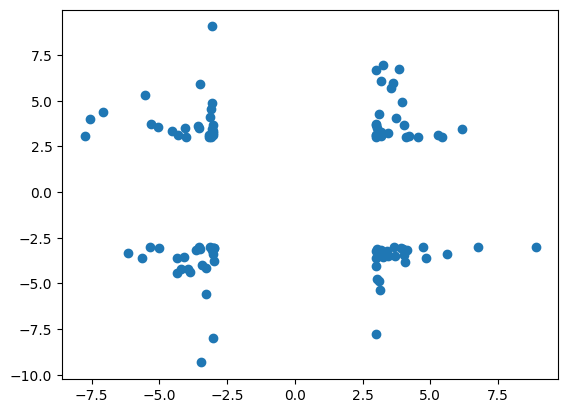

In [1130]:
# Generate data: 4 separable clusters

N = 100
cluster_size = N // 4
cluster_splits = torch.tensor([[-1, 1], [1, 1], [1, -1], [-1, -1]])

X = torch.randn(N, 2) ** 2 + 3
y = torch.empty(N)

for i in range(len(cluster_splits)):
    start, end = i * cluster_size, (i+1)*cluster_size
    X[start:end] *= cluster_splits[i]
    y[start:end] = i
    
import matplotlib.pyplot as plt

plt.scatter(X[:, 0].tolist(), X[:, 1].tolist())


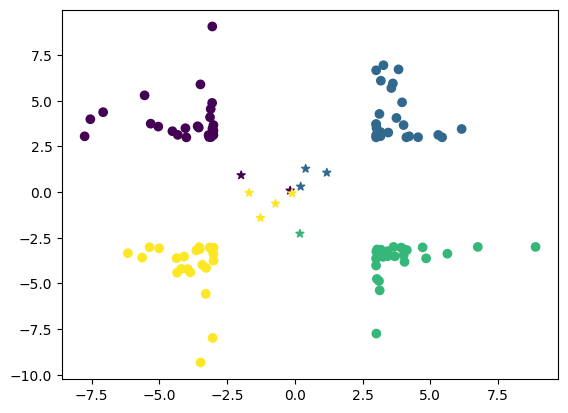

In [1131]:
knn_clf = KNNClassifier(4).fit(X, y)

Z = torch.randn((10, 2))
y_pred = knn_clf.predict(Z)

plt.scatter(X[:, 0].tolist(), X[:, 1].tolist(), c=y.tolist())
plt.scatter(Z[:, 0].tolist(), Z[:, 1].tolist(), marker="*", c=y_pred.tolist())


## 15) k-Means clustering from scratch

**Description**

Implement k-means with random init, assignment, centroid update, stopping.

In [1099]:
import numpy as np
from IPython.display import clear_output

class KMeans:
    def __init__(self, n_clusters: int = 8, init: str = "random", max_iter: int = 300, seed: int = 42, tol=1e-5):
        self.n_clusters = n_clusters
        self.init = init
        self.max_iter = max_iter
        self.rng = np.random.default_rng(seed)
        self.tol = tol

        assert init in ["random"]

    def _init_centroids(self, X: torch.tensor):
        if self.init == "random":
            return X[self.rng.choice(len(X), size=self.n_clusters).tolist()]

    def fit(self, X: torch.tensor):
        centroids = self._init_centroids(X)
        clusters = []
        for i in range(self.max_iter):
            distances = torch.sum((X[:, None] - centroids[None, :])**2, dim=-1)
            clusters = torch.argmin(distances, dim=-1)
            new_centroids = centroids.clone()
            for i in range(self.n_clusters):
                cluster_i = (clusters == i)
                if cluster_i.any():
                    new_centroids[i] = X[cluster_i].mean(dim=0)
                else:
                    new_centroids[i] = X[self.rng.choice(len(X), size=1).tolist()[0]]
            if (centroids - new_centroids).abs().max() < self.tol:
                break
            centroids = new_centroids
            clear_output(wait=True)
            plt.scatter(X[:, 0].tolist(), X[:, 1].tolist(), c=clusters.tolist())
            plt.scatter(new_centroids[:, 0].tolist(), new_centroids[:, 1].tolist(), marker="*")
            plt.show()
        
        self.clusters = clusters
        self.centroids = centroids

        return self


        


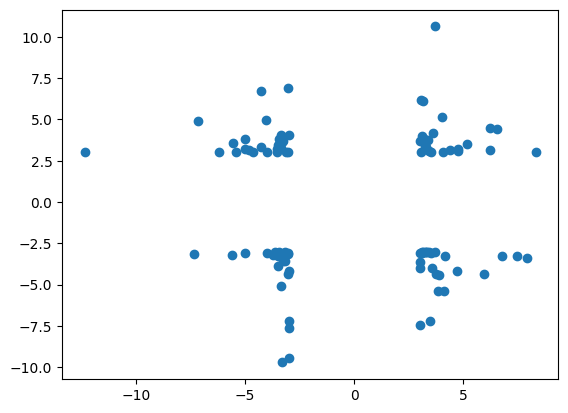

In [1101]:
# Generate data: 4 separable clusters

N = 100
cluster_size = N // 4
cluster_splits = torch.tensor([[-1, 1], [1, 1], [1, -1], [-1, -1]])

X = torch.randn(N, 2) ** 2 + 3

for i in range(len(cluster_splits)):
    start, end = i * cluster_size, (i+1)*cluster_size
    X[start:end] *= cluster_splits[i]
    
import matplotlib.pyplot as plt

plt.scatter(X[:, 0].tolist(), X[:, 1].tolist())


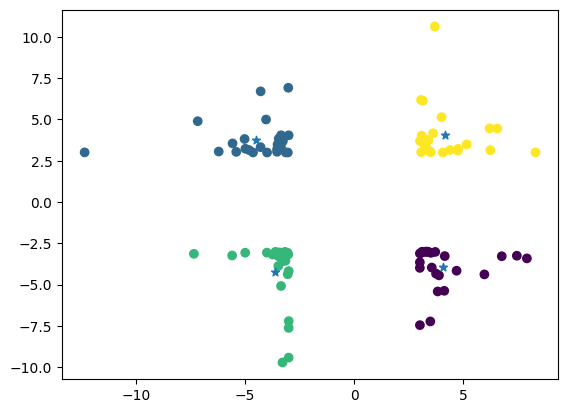

In [1102]:
kmeans_clusters = KMeans(n_clusters=4, seed=4).fit(X)

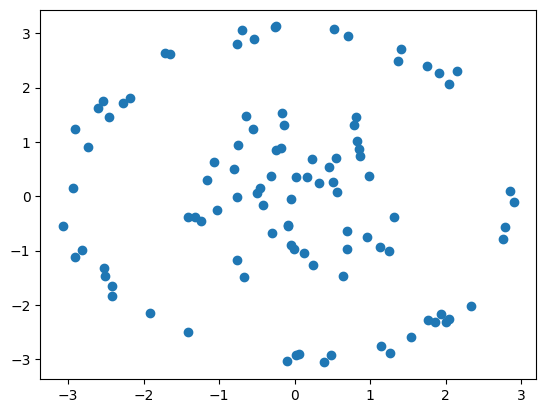

In [1103]:
# Let's test on circle data

r = 3
R = 10

r_circle = []
R_circle = []

while min(len(r_circle), len(R_circle)) < 50:
    random_point = torch.randn(2)
    radius = torch.sum(random_point ** 2).item()
    if len(r_circle) < 50 and radius < r:
        r_circle.append(random_point)
    if len(R_circle) < 50 and r + 5 < radius < R:
        R_circle.append(random_point)


X = torch.stack(r_circle + R_circle, dim=0)

plt.scatter(X[:, 0].tolist(), X[:, 1].tolist())

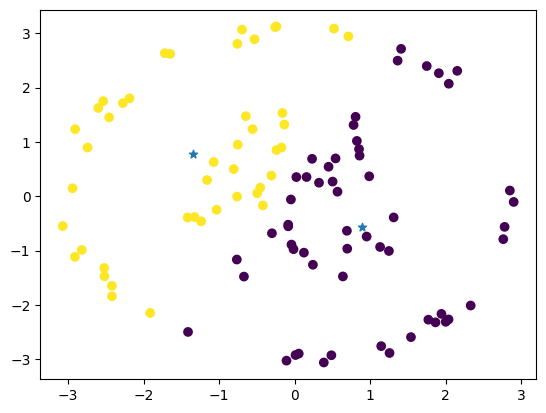

In [1104]:
kmeans_clusters = KMeans(n_clusters=2, seed=1).fit(X)

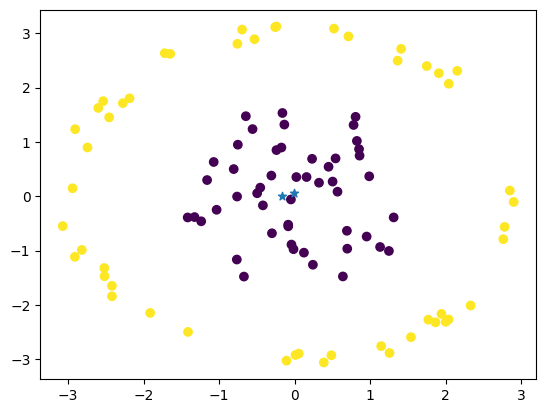

In [1105]:
Y = torch.concat((X, (X[:, 0] ** 2 + X[:, 1]**2)[:, None]), dim=1)
kmeans_clusters = KMeans(n_clusters=2, seed=1).fit(Y)

## 16) PCA via SVD

**Description**

Implement PCA that returns projected data and components.

## 17) Mini MLP forward + manual backprop (2-layer)

**Description**

Build a 2-layer MLP: x -> Linear -> ReLU -> Linear -> logits, and compute gradients manually.

In [1222]:
# input: B x d_in
# f0 = input @ W_0 + b_0, where W_0: d_in x d_model, b_0: d_model
# h1 = ReLU(f0)
# f1 = h1 @ W_1 + b_1, where W_1: d_model x d_out, b_1: d_out

import math
import torch

class MLP2Layers:
    def __init__(self, d_in: int, d_out: int, d_model: int = 64):
        self.d_in = d_in
        self.d_out = d_out
        self.d_model = d_model

        self.W_0 = torch.randn(d_in, d_model) * math.sqrt(4 / (d_in + d_model))
        self.b_0 = torch.zeros(d_model)

        self.W_1 = torch.randn(d_model, d_out) * math.sqrt(4 / (d_model + d_out))
        self.b_1 = torch.zeros(d_out)

    def forward(self, x: torch.Tensor):
        # x: (B, d_in)
        self.f_0 = x @ self.W_0 + self.b_0          # (B, d_model)
        h_1 = torch.relu(self.f_0)                  # (B, d_model)
        f_1 = h_1 @ self.W_1 + self.b_1             # (B, d_out)
        return f_1

    def backward(self, x: torch.Tensor, dL_df1: torch.Tensor):
        # dL_df1: (B, d_out)

        h_1 = torch.relu(self.f_0)

        # Layer 2
        dL_dW1 = h_1.T @ dL_df1                     # (d_model, d_out)
        dL_db1 = dL_df1.sum(dim=0)                  # (d_out,)
        dL_dh1 = dL_df1 @ self.W_1.T                # (B, d_model)

        # ReLU
        relu_mask = (self.f_0 > 0).to(dL_dh1.dtype)
        dL_df0 = relu_mask * dL_dh1                 # (B, d_model)

        # Layer 1
        dL_dW0 = x.T @ dL_df0                       # (d_in, d_model)
        dL_db0 = dL_df0.sum(dim=0)                  # (d_model,)
        dL_dx  = dL_df0 @ self.W_0.T                # (B, d_in)

        return dL_dx, dL_dW0, dL_db0, dL_dW1, dL_db1

        
        
                


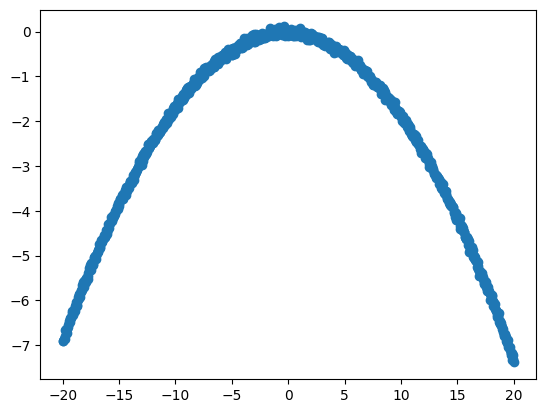

In [1223]:
# 1. Generate data
import torch
import matplotlib.pyplot as plt 
import numpy as np

N = 1000 # num samples
k = 2

X_train = torch.linspace(-20, 20, N).reshape(-1, 1)
W_true = torch.randn(k+1)*0.01
X_degrees = torch.concat(tuple(X_train ** i for i in range(1, k+1)), dim=1)
y_train = X_degrees @ W_true[:k] + W_true[-1] + torch.randn(len(X_degrees))*0.05


# only first feature
plot(X_train, y_train)


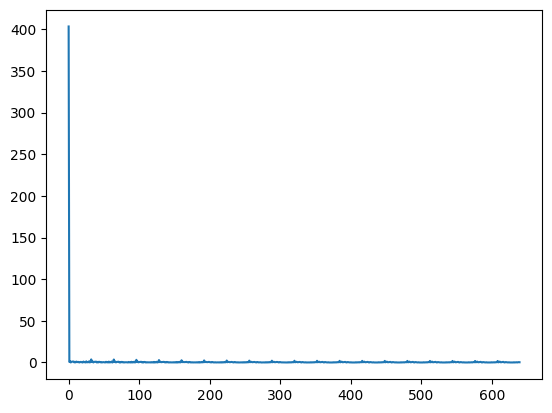

In [1224]:
model = MLP2Layers(d_in=1, d_out=1, d_model=64)
mse_loss = CustomMSELoss()

n_epochs = 1000
batch_size = 32
num_batches = (len(X_train) + batch_size - 1) // num_batches 
lr = 0.0001

train_loss = []



for epoch in range(n_epochs):
    for start in range(0, len(X_train), batch_size):
        X_batch, y_batch = X_train[start:start + batch_size], y_train[start:start + batch_size]
        y_pred = model.forward(X_batch)
        loss = mse_loss(y_batch[:, None], y_pred)

        dL_y = mse_loss.backward()
        _, dL_W_0, dL_b_0, dL_W_1, dL_b_1 = model.backward(X_batch, dL_y)

        model.W_0 -= lr * dL_W_0
        model.W_1 -= lr * dL_W_1
        model.b_0 -= lr * dL_b_0
        model.b_1 -= lr * dL_b_1

        iteration = epoch * num_batches + (start // batch_size)
        if iteration % 50 == 0:
            print()
            clear_output(wait=True)
            train_loss.append(loss.item())
            plt.plot(np.array(train_loss))
            plt.show()


MSE Loss:  0.3498249650001526


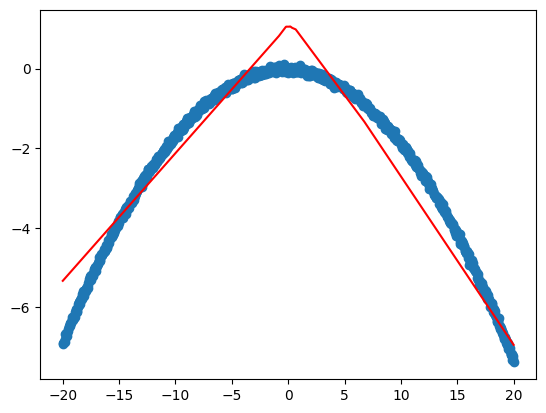

In [1232]:
y_train_pred = model.forward(X_train)
loss = mse_loss(y_train[:, None], y_train_pred)
print(f"MSE Loss: ", loss.item())
plt.scatter(X_train.tolist(), y_train.tolist())
plt.plot(X_train.tolist(), y_train_pred.tolist(), c="red") 


## 18) Gradient checking (finite differences)

**Description**

Implement a function that checks your manual gradient vs finite-diff for one parameter tensor.

## Idea:

Central differences are more stable because they cancel the first-order Taylor error term, giving second-order accuracy while also being more robust to floating-point cancellation.

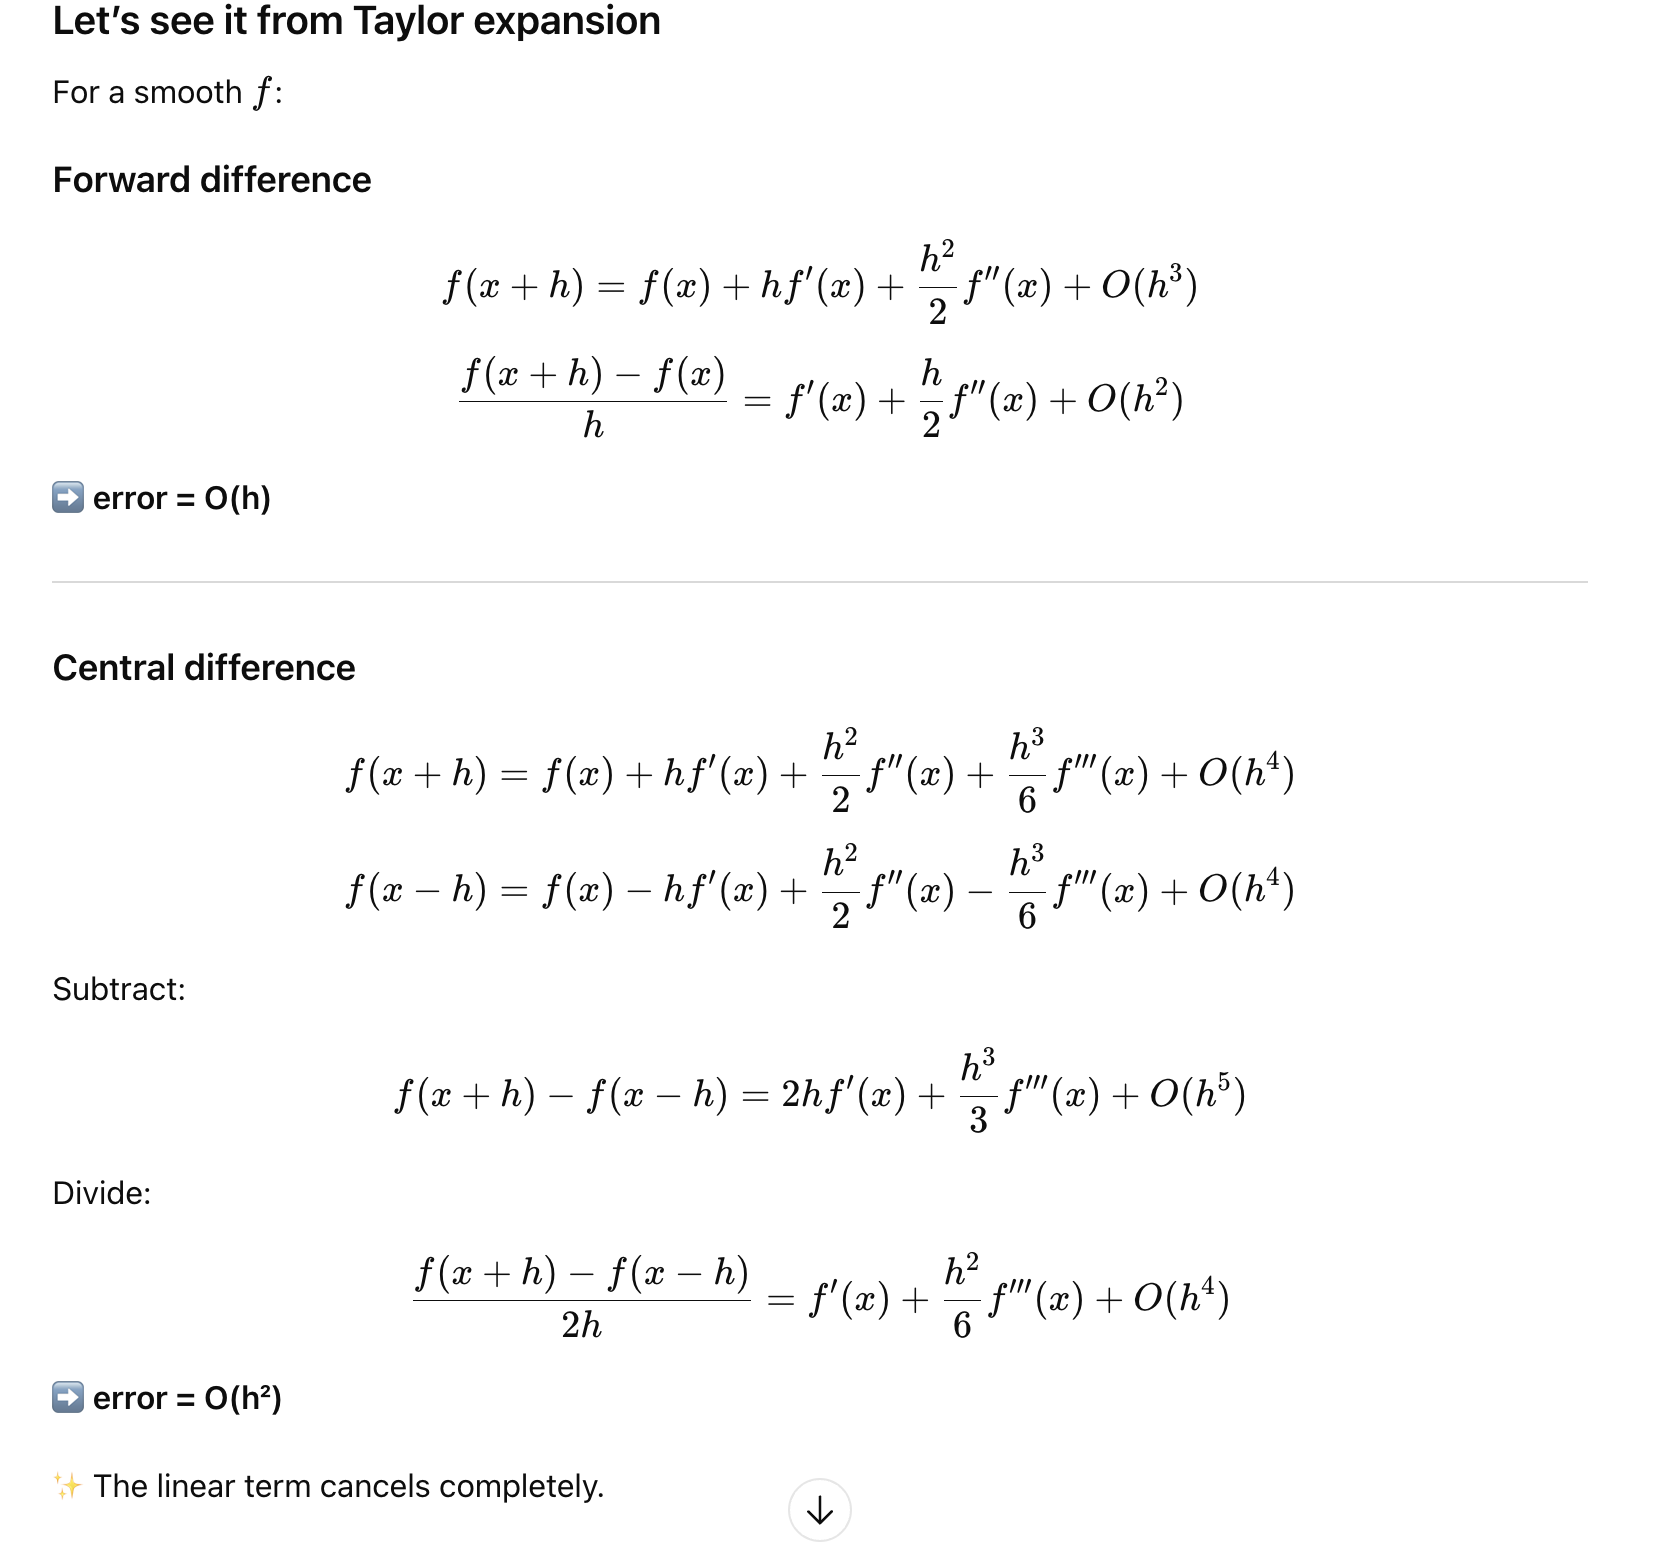

In [1271]:
import torch

def foo(x):
    return x**2 + 5*x

def grad_foo(x):
    return 2*x + 5

def check_grad(foo, grad_foo, trials=100, rtol=1e-5, atol=1e-7):
    hs = [10.0**(-k) for k in range(1, 9)]  # 1e-1 ... 1e-8

    for _ in range(trials):
        x = torch.randn(()).item()

        g_true = grad_foo(x)

        for h in hs:
            g_num = (foo(x + h) - foo(x - h)) / (2*h)

            if not (abs(g_num - g_true) <= atol + rtol * abs(g_true)):
                return False
    return True

print(check_grad(foo, grad_foo))


True


## 19) BatchNorm (training mode) forward + backward (simplified)

**Description**

Implement BatchNorm over features (B, D) with learnable gamma, beta and manual backward.

In [1397]:
import torch

class BatchNorm:
    def __init__(self, d_in: int, momentum: float = 0.1, eps: float = 1e-5):
        self.d_in = d_in
        self.momentum = momentum
        self.eps = eps

        # Learnable parameters (per feature)
        self.gamma = torch.ones(1, d_in, requires_grad=True)
        self.beta = torch.zeros(1, d_in, requires_grad=True)

        # Running statistics
        self.running_mean = torch.zeros(d_in)
        self.running_var = torch.ones(d_in)

        self.train_mode = True

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.train_mode:
            # Batch statistics (population, not unbiased)
            self.batch_mean = x.mean(dim=0)
            self.batch_var = x.var(dim=0, correction=0)

            # Update running statistics (EMA)
            self.running_mean = (
                (1 - self.momentum) * self.running_mean
                + self.momentum * self.batch_mean
            )
            self.running_var = (
                (1 - self.momentum) * self.running_var
                + self.momentum * self.batch_var
            )

            mean = self.batch_mean
            var = self.batch_var
        else:
            mean = self.running_mean
            var = self.running_var

        self.x_hat = (x - mean) / torch.sqrt(var + self.eps)
        out = self.gamma * self.x_hat + self.beta
        return out

    def backward(self, dout: torch.Tensor):
        # Gradients w.r.t. gamma and beta only
        dgamma = torch.sum(dout * self.x_hat, dim=0, keepdim=True)
        dbeta = torch.sum(dout, dim=0, keepdim=True)
        return dgamma, dbeta


In [1398]:
# Test BatchNorm

def test_batch_norm():
    B, D = 100, 20

    input = torch.randn((B, D), requires_grad=True)

    custom_BN = BatchNorm(D)

    
    custom_output = custom_BN.forward(input)

    # Custom Backward
    dO = torch.randn((B, D))
    dgamma, dbetta = custom_BN.backward(dO)

    # Torch Backward
    custom_output.backward(dO)

    # now input.grad, custom_BN.gamma.grad and custom_BN.beta.grad contain true grads calculated by pytorch
    torch.testing.assert_close(custom_BN.gamma.grad, dgamma, rtol=1e-5, atol=1e-5)
    torch.testing.assert_close(custom_BN.beta.grad, dbetta, rtol=1e-5, atol=1e-5)

    print("All tests are passed!!")
    
test_batch_norm()
    

All tests are passed!!


## 20) Dropout forward + backward

**Description**

Implement inverted dropout in training and identity in eval.

In [1403]:
class Dropout:
    def __init__(self, p: float = 0.1):
        self.p = p

        self.training_mode = True

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if not self.training_mode:
            return x
        self.mask = torch.bernoulli(torch.ones_like(x) * (1- self.p))
        out = x * self.mask / (1 - self.p)
        return out

    def backward(self, out_grad: torch.Tensor) -> torch.Tensor:
        if self.training_mode:
            return out_grad * self.mask / (1 - self.p)
        return out_grad


In [1404]:
# Test BatchNorm

def test_dropout():
    B, D = 100, 20

    input = torch.randn((B, D), requires_grad=True)

    custom_dp = Dropout()

    
    custom_output = custom_dp.forward(input)

    # Custom Backward
    dO = torch.randn((B, D))
    dinput= custom_dp.backward(dO)

    # Torch Backward
    custom_output.backward(dO)

    # now input.grad, custom_BN.gamma.grad and custom_BN.beta.grad contain true grads calculated by pytorch
    torch.testing.assert_close(input.grad, dinput, rtol=1e-5, atol=1e-5)

    print("All tests are passed!!")
    
test_dropout()
    

All tests are passed!!


## 21) Backpropagation of scaled dot-product attention (single head)

**Description**

Implement forward + manual backward for scaled dot-product attention:

Inputs:

Q: (B, Tq, D)

K: (B, Tk, D)

V: (B, Tk, D)

Output: O: (B, Tq, D)

Computation:

S = (Q K^T) / sqrt(D) → (B, Tq, Tk)

A = softmax(S, dim=-1) → (B, Tq, Tk)

O = A V → (B, Tq, D)

Assume no mask for simplicity. Your backward must return dQ, dK, dV given dO.

In [1276]:
import math 

class Attention:
    def forward(self, Q: torch.Tensor, K: torch.Tensor, V: torch.Tensor):
        # Q: (B, L, D), K: (B, T, D), V: (B, T, D)
        self.Q = Q
        self.K = K
        self.V = V

        self.scale = 1 / math.sqrt(Q.shape[-1])

        weights = Q@K.transpose(-2, -1) * self.scale # B x L x T
        self.attention_weights = torch.softmax(weights, dim=-1) # B x L x T
        output = self.attention_weights @ V # B x L x D
        return output
    
    def backward(self, dL_output: torch.Tensor):
        # dL_output: B x L x D
        dL_V = self.attention_weights.transpose(-2, -1) @ dL_output  # (B, T, D) 
        dL_attention_weights = dL_output @ self.V.transpose(-2, -1) # (B, L, T) 
        softmax_grad_var = dL_attention_weights * self.attention_weights
        dL_weights = softmax_grad_var - self.attention_weights * softmax_grad_var.sum(dim=-1, keepdim=True) 
        dL_Q = dL_weights @ self.K * self.scale
        dL_K = dL_weights.transpose(-2, -1) @ self.Q * self.scale

        return dL_Q, dL_K, dL_V


In [1279]:
def test_attention_backward():
    torch.manual_seed(0)
    B, L, T, D = 2, 3, 4, 5

    Q = torch.randn(B, L, D, dtype=torch.float64, requires_grad=True)
    K = torch.randn(B, T, D, dtype=torch.float64, requires_grad=True)
    V = torch.randn(B, T, D, dtype=torch.float64, requires_grad=True)

    attn = Attention()

    O = attn.forward(Q, K, V)
    dO = torch.randn_like(O)
    # custom backward
    dQ_custom, dK_custom, dV_custom = attn.backward(dO)
    # autograd backward
    O.backward(dO)

    # compare
    torch.testing.assert_close(dQ_custom, Q.grad, rtol=1e-9, atol=1e-9)
    torch.testing.assert_close(dK_custom, K.grad, rtol=1e-9, atol=1e-9)
    torch.testing.assert_close(dV_custom, V.grad, rtol=1e-9, atol=1e-9)

    print("Passed!!")

test_attention_backward()

Passed!!


## 22) Implement Adam (and optional AdamW) from scratch

**Description**

Write an optimizer that performs an Adam update using .grad from PyTorch params:

For each parameter p at step t:

m = β1 m + (1-β1) g

v = β2 v + (1-β2) g^2

bias-correct:

m̂ = m / (1-β1^t)

v̂ = v / (1-β2^t)

update:

p ← p - lr * m̂ / (sqrt(v̂) + eps)

AdamW differs by applying decoupled weight decay:

p ← p - lr * wd * p (separate from gradient)

In [1350]:
from typing import Tuple, Iterable
from dataclasses import dataclass

@dataclass
class AdamW: 
    def __init__(
            self,
            params: Iterable[torch.nn.parameter.Parameter],
            lr: float = 0.001,
            betas: Tuple[float, float] = (0.9, 0.999),
            eps: float = 1e-8,
            weight_decay: float = 0.01):
        
        self.params = list(params)
        self.lr = lr
        self.betas = betas
        self.eps = eps
        self.weight_decay = weight_decay

        self.update = 0
        self.grad_momentum = [0] * len(self.params)
        self.v_momentum = [0] * len(self.params)


    def zero_grad(self):
        for param in self.params:
            param.grad = None

    def step(self):
        self.update += 1
        with torch.no_grad():
            for i, param in enumerate(self.params):
                if param.grad is not None:
                    self.grad_momentum[i] = self.grad_momentum[i] * self.betas[0] + (1 - self.betas[0]) * param.grad
                    self.v_momentum[i] = self.v_momentum[i] * self.betas[1] + (1 - self.betas[1]) * (param.grad ** 2)

                    m_hat = self.grad_momentum[i] / (1 - self.betas[0] ** self.update)
                    v_hat = self.v_momentum[i] / (1 - self.betas[1] ** self.update)

                    if self.weight_decay != 0:
                        param -= self.lr * self.weight_decay * param

                    param -= self.lr * m_hat / (torch.sqrt(v_hat) + self.eps)



In [1351]:
N=100
k = 5

X_polinomial = torch.randn((N, 1))
W_true = torch.randn(k+1)
X_polinomial = torch.concat(tuple(X_polinomial ** i for i in range(1, k+1)), dim=1)
y_polinomial = X_polinomial @ W_true[:k] + W_true[-1] + torch.randn(len(X_polinomial))*0.05

X_train, y_train, X_test, y_test = split_data(X_polinomial, y_polinomial)

X_train, X_test = normalize_train_test(X_train, X_test)

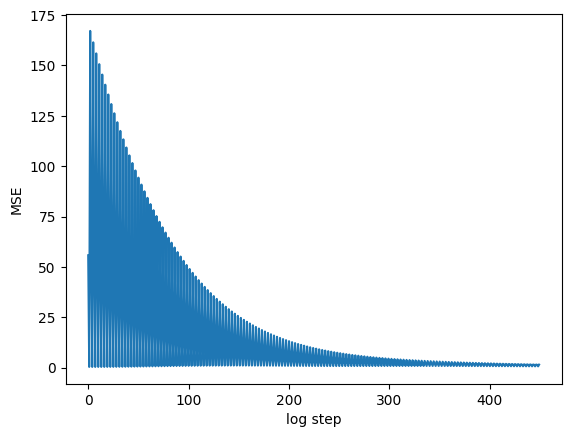

450
Eval loss: 7.454695224761963
Parameter containing:
tensor([[ 0.1997, -2.1699, -2.3308, -3.9899, -3.5270]], requires_grad=True)
Parameter containing:
tensor([-2.8569], requires_grad=True)


In [1355]:
# Torch Optimizer

model = torch.nn.Linear(k, 1) 
mse_loss = torch.nn.MSELoss()
torch_optim = torch.optim.AdamW(model.parameters())

print(len(pytorch_train(X_train, y_train, model, torch_optim, mse_loss, epochs=3000)))
eval(model, X_test, y_test, mse_loss)
for param in model.parameters():
    print(param)

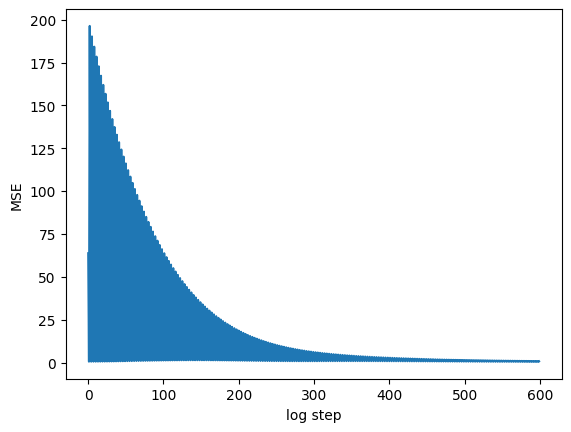

600
Eval loss: 4.709870338439941
Parameter containing:
tensor([[ 0.5284, -1.2885, -2.7500, -4.9331, -3.2349]], requires_grad=True)
Parameter containing:
tensor([-2.8626], requires_grad=True)


In [1356]:
# Custom Optimizer

model = torch.nn.Linear(k, 1) 
mse_loss = torch.nn.MSELoss()
custom_optim = AdamW(model.parameters())

print(len(pytorch_train(X_train, y_train, model, custom_optim, mse_loss, epochs=4000)))
eval(model, X_test, y_test, mse_loss)
for param in model.parameters():
    print(param)

In [2]:
import torch

def topp_sampling(probs: torch.Tensor, p: float = 0.8):
    # Sort probabilities
    sorted_probs, sorted_idx = probs.sort(dim=-1, descending=True)

    # Cumulative sum
    cum_probs = sorted_probs.cumsum(dim=-1)

    # Mask tokens after top-p threshold
    mask = cum_probs <= p
    mask[..., 0] = True  # ensure at least one token

    # Zero out probabilities outside nucleus
    filtered_probs = sorted_probs * mask

    # Renormalize
    filtered_probs = filtered_probs / filtered_probs.sum(dim=-1, keepdim=True)

    # Sample from filtered distribution
    sampled = torch.multinomial(filtered_probs, 1)

    # Map sampled index back to original token index
    next_token = sorted_idx.gather(-1, sampled)

    return next_token

tensor([[-2.3561e+00,  1.0116e+00, -1.3281e-03,  1.7260e+00, -2.0201e+00],
        [ 1.6334e+00,  2.6205e-01, -1.6217e+00,  5.7207e-01,  9.9666e-01],
        [ 1.3569e+00,  1.3037e+00, -5.8055e-01, -2.1163e+00,  1.7699e-01],
        [ 2.1855e-01, -1.4129e+00, -4.3075e-01, -1.9570e-01,  1.5329e+00]]) tensor([[-2.3561e+00, -2.0201e+00, -1.3281e-03,  1.0116e+00,  1.7260e+00],
        [-1.6217e+00,  2.6205e-01,  5.7207e-01,  9.9666e-01,  1.6334e+00],
        [-2.1163e+00, -5.8055e-01,  1.7699e-01,  1.3037e+00,  1.3569e+00],
        [-1.4129e+00, -4.3075e-01, -1.9570e-01,  2.1855e-01,  1.5329e+00]]) tensor([[0, 4, 2, 1, 3],
        [2, 1, 3, 4, 0],
        [3, 2, 4, 1, 0],
        [1, 2, 3, 0, 4]])


In [3]:
def binary_search(arr, k):
    l, r = -1, len(arr) # arr[l] < k <= arr[i]
    while l + 1 < r:
        mid = (l + r) // 2
        if arr[mid] < k:
            l = mid
        else:
            r = mid
    return l

arr = [1,2,3,8,10]
print(binary_search(arr, 5))

2


In [12]:
import torch

x = torch.nn.Parameter(data=torch.randn(3,4))
y = torch.nn.Parameter(data=torch.randn(3,4))

In [19]:
x.add(y)
with torch.no_grad():
    x.add_(y)

In [14]:
x, y

(Parameter containing:
 tensor([[-0.5037, -0.1379, -0.1080,  0.8819],
         [ 1.4170,  0.7204,  0.0690, -0.6032],
         [ 1.3779, -1.0869, -0.1369,  1.0058]], requires_grad=True),
 Parameter containing:
 tensor([[ 0.2256,  0.5002,  1.3197, -1.0047],
         [-0.7532,  0.8748,  0.2224, -1.1848],
         [ 0.7237,  0.5971,  0.1566,  1.0033]], requires_grad=True))

In [20]:
x

Parameter containing:
tensor([[-0.2781,  0.3624,  1.2118, -0.1228],
        [ 0.6638,  1.5952,  0.2913, -1.7880],
        [ 2.1016, -0.4897,  0.0197,  2.0091]], requires_grad=True)